# Introdução PySINDy

Sistema físico:

$$
m\ddot{x} + kx = 0
$$

Como o PySINDy trabalha naturalmente com sistemas de primeira ordem, vamos reescrever o problema usando estados:

$$
x_1 = x
$$

$$
x_2 = v = \dot{x}
$$

Assim:

$$
\dot{x}_1 = x_2
$$

$$
\dot{x}_2 = -\frac{k}{m}x_1
$$

## 1. O que é o PySINDy?

O **PySINDy** é uma biblioteca Python para aplicar o método **SINDy**, sigla para:

> **Sparse Identification of Nonlinear Dynamics**

Ou

> **Identificação Esparsa de Dinâmicas Não Lineares**

A ideia central é descobrir uma equação diferencial a partir de dados medidos ou simulados.

Em vez de você informar diretamente a equação do sistema, você fornece dados do tipo:

$$
x(t), v(t), \theta(t), i(t), \dots
$$

e o método tenta descobrir uma relação do tipo:

$$
\dot{x}(t) = f(x(t))
$$

Para sistemas com vários estados:

$$
\frac{d}{dt}
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{bmatrix}
=
\begin{bmatrix}
f_1(x_1, x_2, \dots, x_n) \\
f_2(x_1, x_2, \dots, x_n) \\
\vdots \\
f_n(x_1, x_2, \dots, x_n)
\end{bmatrix}
$$

No caso do massa–mola, os estados serão:

$$
X =
\begin{bmatrix}
x & v
\end{bmatrix}
$$

e queremos descobrir:

$$
\dot{X} =
\begin{bmatrix}
\dot{x} & \dot{v}
\end{bmatrix}
$$

## 2. Quais dados entram no PySINDy?

O PySINDy precisa, no mínimo, de uma matriz de estados ao longo do tempo.

### 2.1 Matriz de estados `X`

A matriz `X` deve ter o formato:

$$
X =
\begin{bmatrix}
x_1(t_1) & x_2(t_1) & \dots & x_n(t_1) \\
x_1(t_2) & x_2(t_2) & \dots & x_n(t_2) \\
\vdots & \vdots & & \vdots \\
x_1(t_m) & x_2(t_m) & \dots & x_n(t_m)
\end{bmatrix}
$$

No código, isso costuma ser um array com shape:

```python
X.shape == (n_amostras, n_estados)
```

Para o massa–mola:

```python
X[:, 0] = posição x(t)
X[:, 1] = velocidade v(t)
```

Portanto:

```python
X.shape == (n_pontos_no_tempo, 2)
```

### 2.2 Vetor de tempo `t`

Também é necessário informar o tempo. Existem duas formas comuns:

```python
model.fit(X, t=t)
```

onde `t` é um vetor com todos os instantes:

```python
t = [0.00, 0.01, 0.02, ...]
```

ou:

```python
model.fit(X, t=dt)
```

onde `dt` é o passo de tempo constante:

```python
dt = 0.01
```

### 2.3 Derivadas `x_dot` (opcional)

O SINDy precisa comparar os dados com suas derivadas:

$$
\dot{X}
$$

Você pode fornecer essas derivadas diretamente:

```python
model.fit(X, t=t, x_dot=Xdot)
```

ou deixar o PySINDy estimar numericamente:

```python
model.fit(X, t=t)
```

Se os dados tiverem ruído, essa etapa de derivação é crítica, porque derivar numericamente sinal ruidoso pode amplificar muito o ruído.

### 2.4 Entrada de controle `u` (opcional)

Para sistemas forçados ou controlados, também pode existir uma entrada:

$$
\dot{x} = f(x, u)
$$

Exemplos:

- força externa em um sistema massa–mola;
- tensão aplicada em um circuito;
- torque aplicado em um motor;
- sinal de controle de um atuador.

Nesse caso, usa-se algo como:

```python
model.fit(X, t=t, u=U)
```

No nosso exemplo de vibração livre não amortecida, não há entrada externa, então não usaremos `u`.

### 2.5 O ponto mais importante

Para um sistema mecânico de segunda ordem, como:

$$
m\ddot{x} + kx = 0
$$

não é ideal fornecer apenas a posição `x(t)` se você quer identificar um sistema de primeira ordem comum. O estado completo deve incluir posição e velocidade:

$$
X = [x, v]
$$

Isso acontece porque a evolução futura do sistema não depende apenas da posição atual. Ela também depende da velocidade atual.

## 3. Como o SINDy funciona?

A ideia do SINDy é montar uma grande biblioteca de possíveis termos que podem aparecer na equação.

Por exemplo, se os estados forem `x` e `v`, uma biblioteca polinomial poderia conter:

$$
1,\quad x,\quad v,\quad x^2,\quad xv,\quad v^2,\quad x^3,\quad x^2v,\quad xv^2,\quad v^3,\dots
$$

Essa matriz é chamada de:

$$
\Theta(X)
$$

A equação geral do SINDy é:

$$
\dot{X} \approx \Theta(X)\Xi
$$

onde:

- $X$ é a matriz com os estados medidos;
- $\dot{X}$ é a matriz com as derivadas dos estados;
- $\Theta(X)$ é a biblioteca de funções candidatas;
- $\Xi$ é a matriz de coeficientes que o método precisa encontrar.

O ponto central é que o SINDy procura uma solução **esparsa**.

Isso significa que, mesmo oferecendo muitos termos candidatos, o método tenta manter poucos termos ativos.

No massa–mola ideal, por exemplo, a dinâmica real é:

$$
\dot{x} = v
$$

$$
\dot{v} = -\frac{k}{m}x
$$

Ou seja, apesar de uma biblioteca poder conter vários termos, a equação verdadeira só precisa de dois:

- `v` na equação de $\dot{x}$;
- `x` na equação de $\dot{v}$.

Esse é exatamente o tipo de situação em que o SINDy funciona muito bem: a equação é simples quando escrita na base correta.

## 4. Importações

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

try:
    import pysindy as ps
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "O pacote pysindy não está instalado. "
        "Rode a célula anterior com: %pip install pysindy"
    ) from exc

ModuleNotFoundError: O pacote pysindy não está instalado. Rode a célula anterior com: %pip install pysindy

## 5. Definindo o sistema massa–mola

Vamos usar:

$$
m = 1\ \text{kg}
$$

$$
k = 4\ \text{N/m}
$$

Assim:

$$
\omega_n = \sqrt{\frac{k}{m}} = 2\ \text{rad/s}
$$

A equação física é:

$$
m\ddot{x} + kx = 0
$$

Dividindo por $m$:

$$
\ddot{x} = -\frac{k}{m}x
$$

Agora definimos:

$$
v = \dot{x}
$$

Então o sistema de primeira ordem fica:

$$
\dot{x} = v
$$

$$
\dot{v} = -4x
$$

Portanto, esperamos que o PySINDy descubra algo próximo de:

```text
(x)' = 1.000 v
(v)' = -4.000 x
```

In [ ]:
# Parâmetros físicos
m = 1.0  # kg
k = 4.0  # N/m

omega_n = np.sqrt(k / m)

print(f"Frequência natural omega_n = {omega_n:.3f} rad/s")
print(f"Frequência natural f_n = {omega_n / (2*np.pi):.3f} Hz")

Frequência natural omega_n = 2.000 rad/s
Frequência natural f_n = 0.318 Hz


In [ ]:
def massa_mola_livre(t, z, m, k):
    x, v = z

    dxdt = v
    dvdt = -(k / m) * x

    return [dxdt, dvdt]

## 6. Simulando os dados

Agora vamos gerar dados sintéticos.

Condição inicial:

$$
x(0) = 1
$$

$$
v(0) = 0
$$

Ou seja, a massa começa deslocada e é solta do repouso.

A solução esperada é uma oscilação senoidal sem amortecimento.

In [ ]:
# Tempo de simulação
t0 = 0.0
tf = 10.0
n_pontos = 1001

t = np.linspace(t0, tf, n_pontos)

# Condição inicial
x0 = 1.0
v0 = 0.0
z0 = [x0, v0]

sol = solve_ivp(
    fun=lambda t, z: massa_mola_livre(t, z, m, k),
    t_span=(t0, tf),
    y0=z0,
    t_eval=t,
    rtol=1e-10,
    atol=1e-12
)

# Matriz de estados no formato esperado pelo PySINDy:
# cada linha é um instante de tempo
# cada coluna é uma variável de estado
X = sol.y.T

print("Formato de X:", X.shape)
print("Primeiras linhas de X:")
pd.DataFrame(X[:5], columns=["x", "v"])

Formato de X: (1001, 2)
Primeiras linhas de X:


,x,v
0,1.000000,0.000000
1,0.999800,-0.039997
2,0.999200,-0.079979
3,0.998201,-0.119928
4,0.996802,-0.159829


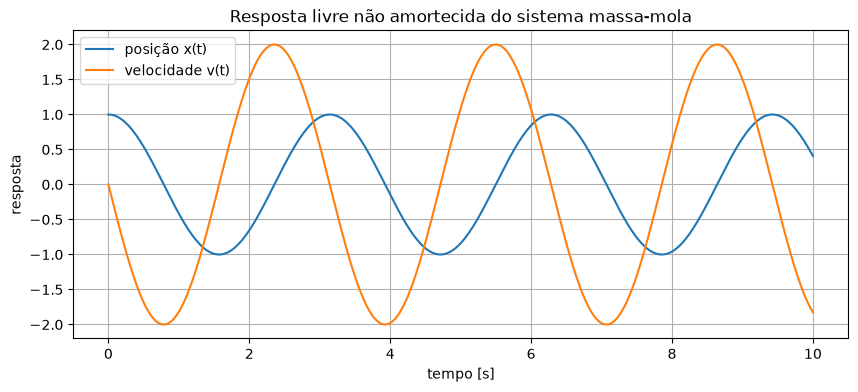

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(t, X[:, 0], label="posição x(t)")
plt.plot(t, X[:, 1], label="velocidade v(t)")
plt.xlabel("Tempo [s]")
plt.ylabel("Resposta")
plt.title("Resposta livre não amortecida do sistema massa-mola")
plt.legend()
plt.grid(True)
plt.show()

## 7. Montando manualmente o problema do SINDy

Antes de usar o PySINDy, vamos montar a ideia principal manualmente.

Sabemos que:

$$
\dot{x} = v
$$

$$
\dot{v} = -\frac{k}{m}x
$$

Como estamos simulando o sistema, conseguimos calcular as derivadas verdadeiras:

$$
\dot{X} =
\begin{bmatrix}
\dot{x} & \dot{v}
\end{bmatrix}
=
\begin{bmatrix}
v & -\frac{k}{m}x
\end{bmatrix}
$$

In [ ]:
# Derivadas verdadeiras dos estados
Xdot_true = np.column_stack([
    X[:, 1],              # dx/dt = v
    -(k / m) * X[:, 0]    # dv/dt = -(k/m)x
])

print("Formato de Xdot_true:", Xdot_true.shape)

pd.DataFrame(
    np.column_stack([X[:5], Xdot_true[:5]]),
    columns=["x", "v", "x_dot", "v_dot"]
)

Formato de Xdot_true: (1001, 2)


,x,v,x_dot,v_dot
0,1.000000,0.000000,0.000000,-4.000000
1,0.999800,-0.039997,-0.039997,-3.999200
2,0.999200,-0.079979,-0.079979,-3.996800
3,0.998201,-0.119928,-0.119928,-3.992802
4,0.996802,-0.159829,-0.159829,-3.987207


Vamos escolher uma biblioteca simples:

$$
\Theta(X) = [x,\ v]
$$

Ou seja, estamos perguntando:

> Será que as derivadas podem ser escritas como combinação linear de posição e velocidade?

Matematicamente:

$$
\begin{bmatrix}
\dot{x} & \dot{v}
\end{bmatrix}
\approx
\begin{bmatrix}
x & v
\end{bmatrix}
\begin{bmatrix}
\xi_{x,\dot{x}} & \xi_{x,\dot{v}} \\
\xi_{v,\dot{x}} & \xi_{v,\dot{v}}
\end{bmatrix}
$$

Esperamos encontrar:

$$
\dot{x} = 0x + 1v
$$

$$
\dot{v} = -4x + 0v
$$

In [ ]:
# Biblioteca manual: Theta = [x, v]
Theta = np.column_stack([
    X[:, 0],  # x
    X[:, 1]   # v
])

# Regressão por mínimos quadrados:
# queremos Xi tal que Xdot_true ≈ Theta @ Xi
Xi, residuals, rank, singular_values = np.linalg.lstsq(Theta, Xdot_true, rcond=None)

coef_manual = pd.DataFrame(
    Xi,
    index=["x", "v"],
    columns=["coeficiente em x_dot", "coeficiente em v_dot"]
)

coef_manual

,coeficiente em x_dot,coeficiente em v_dot
x,-2.742780e-17,-4.000000e+00
v,1.000000e+00,4.741023e-17


Interpretando a tabela:

- Na coluna `coeficiente em x_dot`, o termo `v` deve aparecer com coeficiente próximo de `1`.
- Na coluna `coeficiente em v_dot`, o termo `x` deve aparecer com coeficiente próximo de `-4`.

Logo:

$$
\dot{x} \approx v
$$

$$
\dot{v} \approx -4x
$$

Essa é a essência do SINDy: montar candidatos e encontrar os coeficientes.  
A diferença é que o PySINDy faz isso de forma mais geral, permitindo bibliotecas maiores e otimizadores que forçam esparsidade.

## 8. Identificando o modelo com PySINDy usando derivadas conhecidas

Agora vamos usar o PySINDy de fato.

Nesta primeira versão, vamos fornecer `Xdot_true` diretamente.

Isso representa um caso ideal:

- temos os estados `X`;
- temos as derivadas `Xdot`;
- queremos que o PySINDy encontre a equação.

Vamos usar:

```python
PolynomialLibrary(degree=1, include_bias=False)
```

Isso significa que a biblioteca terá apenas termos lineares:

$$
x,\quad v
$$

Como sabemos que o massa–mola ideal é linear, isso é suficiente.

In [ ]:
# Biblioteca de funções candidatas
feature_library = ps.PolynomialLibrary(
    degree=1,
    include_bias=False
)

# Otimizador esparso
optimizer = ps.STLSQ(
    threshold=1e-8,
    alpha=0.0
)

# Modelo SINDy
model = ps.SINDy(
    feature_library=feature_library,
    optimizer=optimizer
)

# Ajuste do modelo
model.fit(
    X,
    t=t,
    x_dot=Xdot_true,
    feature_names=["x", "v"]
)

# Equações identificadas
model.print(precision=5)

(x)' =  1.00000 v
(v)' = -4.00000 x


Isso significa que o PySINDy recuperou exatamente a forma do modelo físico.

In [ ]:
# Visualizando os coeficientes em tabela
coeficientes = pd.DataFrame(
    model.coefficients(),
    index=["x_dot", "v_dot"],
    columns=model.get_feature_names()
)

coeficientes

,x,v
x_dot,0.0,1.0
v_dot,-4.0,0.0


## 9. Usando uma biblioteca maior

Agora vamos testar uma situação mais parecida com o uso real.

Imagine que você não sabe se o sistema é linear ou não.  
Então você oferece uma biblioteca maior, com termos até grau 3:

$$
x,\quad v,\quad x^2,\quad xv,\quad v^2,\quad x^3,\quad x^2v,\quad xv^2,\quad v^3
$$

O método deve perceber que quase todos esses termos são desnecessários.

Para isso, usamos um `threshold` maior no otimizador. Esse parâmetro ajuda a eliminar coeficientes pequenos.

In [ ]:
feature_library_grau3 = ps.PolynomialLibrary(
    degree=3,
    include_bias=False
)

optimizer_grau3 = ps.STLSQ(
    threshold=0.5,
    alpha=1e-8
)

model_grau3 = ps.SINDy(
    feature_library=feature_library_grau3,
    optimizer=optimizer_grau3
)

model_grau3.fit(
    X,
    t=t,
    x_dot=Xdot_true,
    feature_names=["x", "v"]
)

model_grau3.print(precision=5)

NameError: name 'ps' is not defined

In [ ]:
coeficientes_grau3 = pd.DataFrame(
    model_grau3.coefficients(),
    index=["x_dot", "v_dot"],
    columns=model_grau3.get_feature_names()
)

coeficientes_grau3

,x,v,x^2,x v,v^2,x^3,x^2 v,x v^2,v^3
x_dot,0.000000,0.515152,0.0,0.0,0.0,0.000000,0.484848,0.000000,0.121212
v_dot,-2.060606,0.000000,0.0,0.0,0.0,-1.939394,0.000000,-0.484848,0.000000


Mesmo oferecendo vários termos candidatos, o esperado é que o modelo mantenha apenas:

- `v` na equação de `x_dot`;
- `x` na equação de `v_dot`.

Isso mostra a ideia de **esparsidade**: o modelo mais simples que explica bem os dados é preferido.

## 10. Deixando o PySINDy estimar as derivadas

Na prática, muitas vezes você mede apenas os estados:

$$
X = [x, v]
$$

e não mede diretamente:

$$
\dot{X}
$$

Nesse caso, o PySINDy pode estimar numericamente as derivadas a partir dos dados e do vetor de tempo.

Agora faremos:

```python
model.fit(X, t=t)
```

sem passar `x_dot`.

In [ ]:
model_sem_xdot = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=1, include_bias=False),
    optimizer=ps.STLSQ(threshold=1e-6, alpha=1e-8),
    differentiation_method=ps.FiniteDifference(order=2)
)

model_sem_xdot.fit(
    X,
    t=t,
    feature_names=["x", "v"]
)

model_sem_xdot.print(precision=5)

(x)' =  0.99993 v
(v)' = -3.99974 x


Como os dados simulados são muito limpos, o modelo ainda deve ficar muito próximo do correto.

Mas em dados experimentais reais, especialmente com ruído, essa etapa pode piorar bastante.  
Por isso, em problemas reais, vale testar métodos de diferenciação mais robustos ou suavizar os dados antes de derivar.

## 11. Simulando o modelo identificado

Depois que o PySINDy identifica o modelo, podemos simular a dinâmica aprendida e comparar com a simulação original.

A ideia é:

1. pegar a mesma condição inicial;
2. simular o modelo identificado;
3. comparar com os dados originais.

In [ ]:
X_sindy = model.simulate(
    x0=X[0],
    t=t
)

print("Formato de X_sindy:", X_sindy.shape)

Formato de X_sindy: (1001, 2)


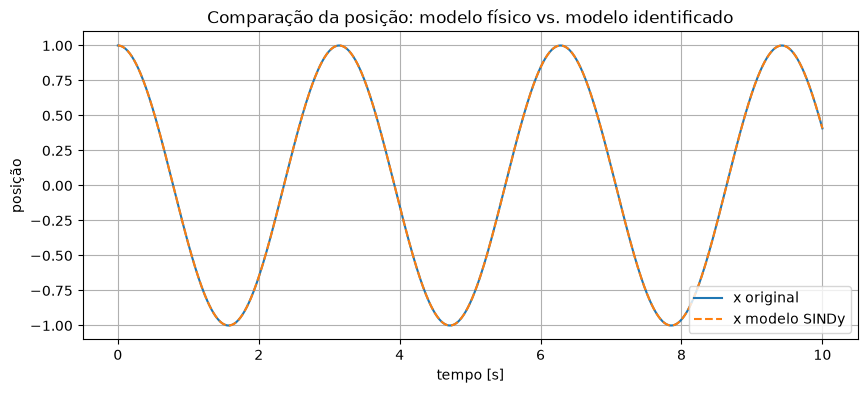

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(t, X[:, 0], label="x original")
plt.plot(t, X_sindy[:, 0], "--", label="x modelo SINDy")
plt.xlabel("tempo [s]")
plt.ylabel("posição")
plt.title("Comparação da posição: modelo físico vs. modelo identificado")
plt.legend()
plt.grid(True)
plt.show()

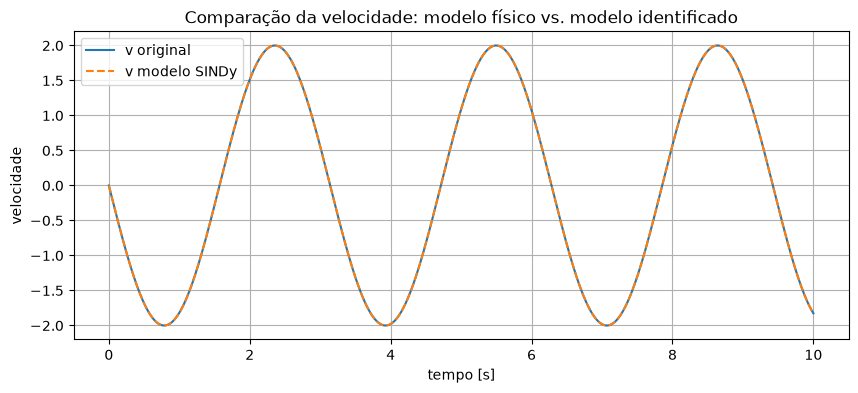

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(t, X[:, 1], label="v original")
plt.plot(t, X_sindy[:, 1], "--", label="v modelo SINDy")
plt.xlabel("tempo [s]")
plt.ylabel("velocidade")
plt.title("Comparação da velocidade: modelo físico vs. modelo identificado")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
erro_x = X[:, 0] - X_sindy[:, 0]
erro_v = X[:, 1] - X_sindy[:, 1]

rmse_x = np.sqrt(np.mean(erro_x**2))
rmse_v = np.sqrt(np.mean(erro_v**2))

print(f"RMSE posição:    {rmse_x:.3e}")
print(f"RMSE velocidade: {rmse_v:.3e}")

RMSE posição:    9.911e-11
RMSE velocidade: 1.872e-10


## 12. Teste opcional com ruído

Agora vamos adicionar ruído aos estados.

Isso é importante porque dados reais raramente são perfeitos.  
O problema é que derivadas numéricas são muito sensíveis a ruído.

Vamos criar uma versão ruidosa dos dados e tentar identificar novamente o modelo.

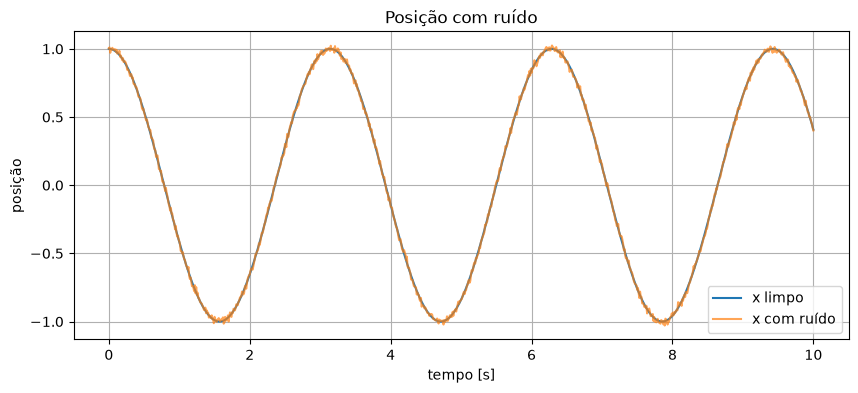

In [ ]:
rng = np.random.default_rng(42)

nivel_ruido = 0.02  # 2% do desvio padrão de cada variável
escala = X.std(axis=0)

X_ruidoso = X + nivel_ruido * escala * rng.normal(size=X.shape)

plt.figure(figsize=(10, 4))
plt.plot(t, X[:, 0], label="x limpo")
plt.plot(t, X_ruidoso[:, 0], alpha=0.7, label="x com ruído")
plt.xlabel("tempo [s]")
plt.ylabel("posição")
plt.title("Posição com ruído")
plt.legend()
plt.grid(True)
plt.show()

Para lidar melhor com o ruído, vamos usar uma diferenciação suavizada:

```python
SmoothedFiniteDifference()
```

A ideia não é que isso resolva todo problema experimental, mas mostra um caminho comum: suavizar antes ou durante a diferenciação.

In [ ]:
model_ruidoso = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=1, include_bias=False),
    optimizer=ps.STLSQ(threshold=0.05, alpha=1e-5),
    differentiation_method=ps.SmoothedFiniteDifference()
)

model_ruidoso.fit(
    X_ruidoso,
    t=t,
    feature_names=["x", "v"]
)

model_ruidoso.print(precision=5)

(x)' =  0.99994 v
(v)' = -4.00203 x


Com ruído, os coeficientes podem não sair exatamente iguais a `1` e `-4`.

Isso é esperado.

Em problemas reais, os principais ajustes costumam ser:

- escolher melhor quais estados entram em `X`;
- melhorar a qualidade dos dados;
- filtrar/suavizar sinais antes de derivar;
- testar diferentes métodos de diferenciação;
- ajustar o `threshold` do otimizador;
- escolher uma biblioteca de funções coerente com a física do problema;
- usar múltiplas trajetórias com condições iniciais diferentes.

## 13. Resumo prático

### O que entra no PySINDy?

Para um sistema contínuo típico:

```python
model.fit(X, t=t)
```

onde:

- `X`: matriz de estados, com shape `(n_amostras, n_estados)`;
- `t`: vetor de tempo ou passo `dt`.

Opcionalmente:

```python
model.fit(X, t=t, x_dot=Xdot)
```

onde:

- `x_dot`: derivadas dos estados, com o mesmo shape de `X`.

Para sistemas com entrada:

```python
model.fit(X, t=t, u=U)
```

onde:

- `U`: entradas ou controles do sistema.

### Como o método funciona?

O SINDy resolve aproximadamente:

$$
\dot{X} \approx \Theta(X)\Xi
$$

Ele faz isso em três etapas conceituais:

1. **Deriva os dados**, se você não fornecer `x_dot`.
2. **Monta uma biblioteca de funções candidatas**, como $x$, $v$, $x^2$, $xv$, $\sin(x)$ etc.
3. **Faz regressão esparsa** para manter apenas os termos mais importantes.

### O que ele deveria descobrir no massa–mola?

Para:

$$
m = 1
$$

$$
k = 4
$$

a equação real é:

$$
\dot{x} = v
$$

$$
\dot{v} = -4x
$$

Portanto, o resultado esperado é:

```text
(x)' = 1.000 v
(v)' = -4.000 x
```

### Cuidado importante

Se o sistema é de segunda ordem, como um sistema mecânico, normalmente você deve transformar em primeira ordem antes:

$$
X = [x, v]
$$

Fornecer apenas $x(t)$ pode ser insuficiente, porque a dinâmica futura depende também da velocidade.

## 14. Referências úteis

- Documentação oficial do PySINDy: https://pysindy.readthedocs.io/
- Classe `pysindy.SINDy`: https://pysindy.readthedocs.io/en/stable/generated/pysindy.SINDy.html
- Introdução ao método SINDy na documentação: https://pysindy.readthedocs.io/en/latest/summary.html
- Tutorial de geração de dados e ajuste: https://pysindy.readthedocs.io/en/latest/examples/tutorial_1/example.html
- Dicas práticas da documentação: https://pysindy.readthedocs.io/en/stable/tips.html
- Artigo original do SINDy: Brunton, Proctor e Kutz, *Discovering governing equations from data by sparse identification of nonlinear dynamical systems*, PNAS, 2016.